In [1]:
!pip install leidenalg
import pandas as pd
import igraph as ig
import leidenalg as la
from collections import Counter

## Data preparation

We decided to use the year of the deal’s conclusion rather than the year of delivery, as it better reflects the structure of political alliances.

In [2]:
df = pd.read_csv("trade-register.csv", skiprows=11, encoding="latin-1")
df.columns = df.columns.str.strip()
 
df = df[["Recipient", "Supplier", "Year of order",
         "SIPRI TIV of delivered weapons"]].copy()
df.columns = ["recipient", "supplier", "year", "tiv"]
 
df = df.dropna(subset=["recipient", "supplier", "year"])

Then we excluded non-state actors, following the approach of Lebacher et al. (2021):

In [3]:
# Drop non-state actors (marked "*") and unknown
df = df[~df["recipient"].str.endswith("*")]
df = df[~df["supplier"].str.endswith("*")]
df = df[~df["recipient"].str.contains("unknown", case=False, na=False)]
df = df[~df["supplier"].str.contains("unknown", case=False, na=False)]

In [4]:
# drop NA
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df.dropna(subset=["year"])
df["year"] = df["year"].astype(int)

In [5]:
# 2025 incomplete, 1940s only a few deals
df = df[(df["year"] >= 1950) & (df["year"] <= 2024)]

In [6]:
# Some pre-1992 deals are recorded under "Russia" although the USSR still existed.
mask = (df["supplier"] == "Russia") & (df["year"] < 1992)
df.loc[mask, "supplier"] = "Soviet Union"
mask = (df["recipient"] == "Russia") & (df["year"] < 1992)
df.loc[mask, "recipient"] = "Soviet Union"

We split the data into five-year windows to create the temporal layers needed to track how the network's community structure changes over time:

In [7]:
def window_label(year):
    start = (year // 5) * 5
    return f"{start}-{start + 4}"
df["window"] = df["year"].apply(window_label)

**ALL_WINDOWS**: fifteen 5-year windows covering SIPRI's full period (1950-2024); these are the temporal layers for the multilayer analysis.

**KEY_WINDOWS**: four windows for in-depth exploratory analysis, chosen as structurally distinct regimes of the arms trade system:

- 1960-1964  mature bipolar Cold War
- 1980-1984  late Cold War, last stable bipolar regime
- 1995-1999  post-Soviet reconfiguration (the 1990-94 transition is skipped)
- 2020-2024  contemporary multipolar structure

*None of these windows crosses the 1991 dissolution, so the set of actors in each is unambiguous.*

In [8]:
ALL_WINDOWS = [f"{s}-{s+4}" for s in range(1950, 2021, 5)] 
KEY_WINDOWS = ["1960-1964", "1980-1984", "1995-1999", "2020-2024"]
 
print("rows:", len(df), "| years:", df["year"].min(), "-", df["year"].max())

rows: 28724 | years: 1950 - 2024


## Graphs

In [9]:
def edge_set(data, window):
    """Directed (supplier -> recipient) pairs, binary, no self-loops."""
    sub = data[data["window"] == window]
    return {(s, r) for s, r in zip(sub["supplier"], sub["recipient"]) if s != r}

In [10]:
def build_undirected(data, window):
    """Undirected binary graph for community detection."""
    und = {tuple(sorted(p)) for p in edge_set(data, window)}
    countries = sorted({c for p in und for c in p})
    g = ig.Graph()
    g.add_vertices(countries)
    g.add_edges(list(und))
    return g

In [11]:
def build_directed(data, window):
    """Directed binary graph (used only for in/out-degree)."""
    directed = edge_set(data, window)
    countries = sorted({c for p in directed for c in p})
    g = ig.Graph(directed=True)
    g.add_vertices(countries)
    g.add_edges(list(directed))
    return g

## Analysis functions

Analysis overview:

1. **Exploratory analysis** -- four structurally distinct windows (1960–64, 1980–84, 1995–99, 2020–24), each examined with connectivity measures, Louvain with a resolution sweep, and k-cores. We compare methods to check robustness: we report Louvain and Walktrap but drop Edge Betweenness, which over-fragments these dense networks.
2. **Multilayer analysis** -- temporal community detection across all 15 windows (Mucha et al. 2010) to track how subgroups form, persist, and reorganise from 1950 to 2024.

In [12]:
def basic_metrics(g):                                
    comps = g.connected_components()
    giant = comps.giant()
    print(f"  density:          {g.density():.4f}")
    print(f"  components:       {len(comps)} (largest: {giant.vcount()})")
    print(f"  clustering:       {g.transitivity_undirected():.3f}")
    print(f"  avg path (giant): {giant.average_path_length():.2f}")

In [13]:
def louvain_sweep(g, resolutions): 
    print("  resolution -> number of communities:")
    for r in resolutions:
        p = g.community_multilevel(resolution=r)
        print(f"    {r:.2f} -> {len(p)}")

In [14]:
def three_methods(g, resolution):
    louvain  = g.community_multilevel(resolution=resolution)   # 8.4.2.4 modularity
    walktrap = g.community_walktrap().as_clustering()          # 8.4.2.3 diffusion
    eb       = g.community_edge_betweenness().as_clustering()  # 8.4.2.2 divisive
    print(f"  Louvain:          {len(louvain)} comms (modularity {louvain.modularity:.3f})")
    print(f"  Walktrap:         {len(walktrap)} comms (modularity {walktrap.modularity:.3f})")
    print(f"  Edge betweenness: {len(eb)} comms (modularity {eb.modularity:.3f})")
    return louvain, walktrap, eb

*The fourth class disscussed in the chapter, **spectral methods**, is not used: the chapter notes that spectral approaches tend to underperform on small-to-medium networks, which is exactly the size of our windows (~120-160 countries).*

In [15]:
def show_communities(g, partition, min_size=4):
    for i, comm in enumerate(partition):
        names = [g.vs[v]["name"] for v in comm]
        if len(names) >= min_size:
            print(f"    Community {i} ({len(names)}): {', '.join(names)}")

In [16]:
def k_cores(g, top=8):                            
    cores = g.coreness()
    ranked = sorted(zip(g.vs["name"], cores), key=lambda x: -x[1])
    print("  Core (top coreness): " +
          ", ".join(f"{n}(k={c})" for n, c in ranked[:top]))

In [17]:
def direction_summary(data, window, top=6):
    """Direction kept descriptively: top exporters / importers."""
    gd = build_directed(data, window)
    outd = sorted(zip(gd.vs["name"], gd.outdegree()), key=lambda x: -x[1])
    ind  = sorted(zip(gd.vs["name"], gd.indegree()),  key=lambda x: -x[1])
    print("  Top exporters (out-degree): " +
          ", ".join(f"{n}({d})" for n, d in outd[:top] if d > 0))
    print("  Top importers (in-degree):  " +
          ", ".join(f"{n}({d})" for n, d in ind[:top] if d > 0))

In [18]:
def analyze_window(data, window, resolution=1.0):
    g = build_undirected(data, window)
    print(f"\n=== WINDOW {window} ===")
    basic_metrics(g)
    louvain_sweep(g, [0.5, 0.75, 1.0, 1.25, 1.5])
    lv, wt, eb = three_methods(g, resolution)
    print("  Communities (Louvain):")
    show_communities(g, lv)
    k_cores(g)
    direction_summary(data, window)
    return g, lv

## STAGE A: in-depth analysis of key windows

In [24]:
for w in KEY_WINDOWS:
    analyze_window(df, w, resolution=1.0)


=== WINDOW 1960-1964 ===
  density:          0.0452
  components:       1 (largest: 120)
  clustering:       0.148
  avg path (giant): 2.44
  resolution -> number of communities:
    0.50 -> 2
    0.75 -> 4
    1.00 -> 5
    1.25 -> 7
    1.50 -> 9
  Louvain:          5 comms (modularity 0.360)
  Walktrap:         2 comms (modularity 0.233)
  Edge betweenness: 42 comms (modularity 0.191)
  Communities (Louvain):
    Community 0 (28): Afghanistan, Albania, Algeria, Bulgaria, China, Cuba, Czechoslovakia, East Germany (GDR), Egypt, Ethiopia, Guinea, Hungary, India, Indonesia, Mali, Mongolia, Morocco, Myanmar, North Korea, North Yemen, Poland, Romania, Somalia, Soviet Union, Syria, Tanzania, Viet Nam, Yugoslavia
    Community 1 (28): Argentina, Australia, Brazil, Brunei, Cameroon, Canada, Colombia, Dominican Republic, Ghana, Iraq, Jamaica, Jordan, Kenya, Kuwait, Libya, Malawi, Mexico, Nepal, Oman, Pakistan, Paraguay, Peru, Saudi Arabia, Trinidad and Tobago, United Kingdom, Venezuela, Zamb

### Visualisation

In [30]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

def plot_blocks(data, window, resolution=1.0):
    g = build_undirected(data, window)
    part = g.community_multilevel(resolution=resolution)
    deg = g.degree()
 
    # Pull communities apart: intra-community edges get higher layout weight.
    w = [5.0 if part.membership[e.source] == part.membership[e.target]
         else 0.3 for e in g.es]
    layout = g.layout_fruchterman_reingold(weights=w, niter=2000)
    coords = layout.coords
    xs = [c[0] for c in coords]; ys = [c[1] for c in coords]
 
    palette = plt.get_cmap("tab10")
    big = [cid for cid, sz in Counter(part.membership).items() if sz >= 5]
    cmap = {cid: palette(i % 10) for i, cid in enumerate(big)}
    node_colors = [cmap.get(c, (0.8, 0.8, 0.8, 1)) for c in part.membership]
    node_sizes = [40 + 18 * d for d in deg]
 
    fig, ax = plt.subplots(figsize=(13, 13))
    for e in g.es:
        x0, y0 = coords[e.source]; x1, y1 = coords[e.target]
        same = part.membership[e.source] == part.membership[e.target]
        ax.plot([x0, x1], [y0, y1], color="gray",
                alpha=0.25 if same else 0.06, lw=0.4, zorder=1)
    ax.scatter(xs, ys, s=node_sizes, c=node_colors,
               edgecolors="black", linewidths=0.4, zorder=2)
    thr = sorted(deg, reverse=True)[min(18, len(deg) - 1)]
    for i, name in enumerate(g.vs["name"]):
        if deg[i] >= thr:
            ax.text(xs[i], ys[i], name, fontsize=8, ha="center",
                    va="center", fontweight="bold", zorder=3)
    ax.set_title(f"Arms trade communities, {window} "
                 f"(node size = number of partners; modularity {part.modularity:.2f})",
                 fontsize=13)
    ax.axis("off")
    handles = [mpatches.Patch(color=cmap[cid],
               label=f"Community {cid} (n={Counter(part.membership)[cid]})")
               for cid in big]
    ax.legend(handles=handles, loc="upper left", fontsize=9, framealpha=0.9)
    plt.tight_layout(); plt.show()

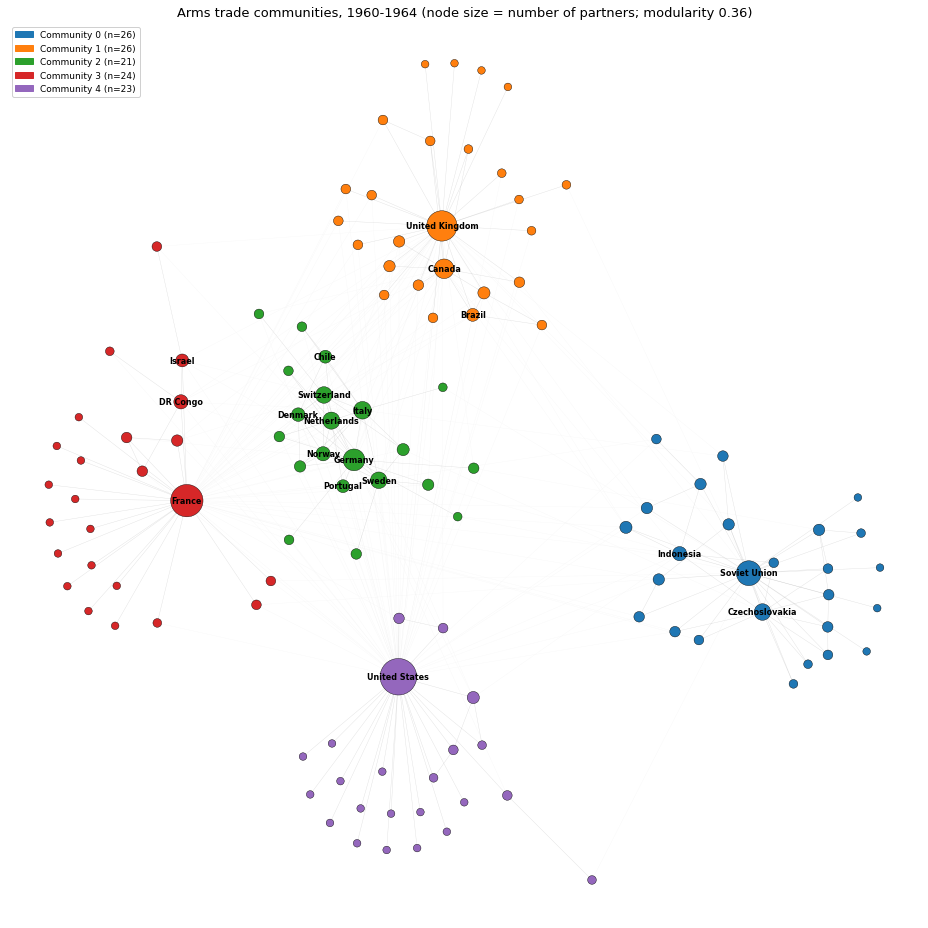

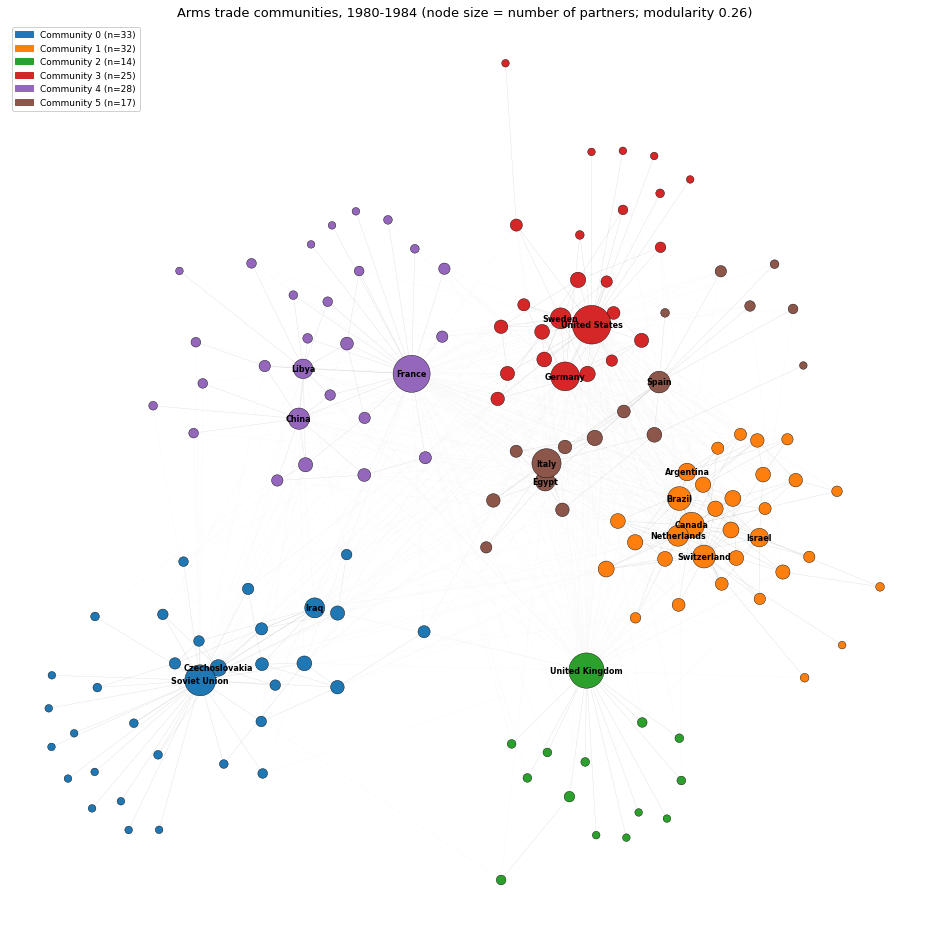

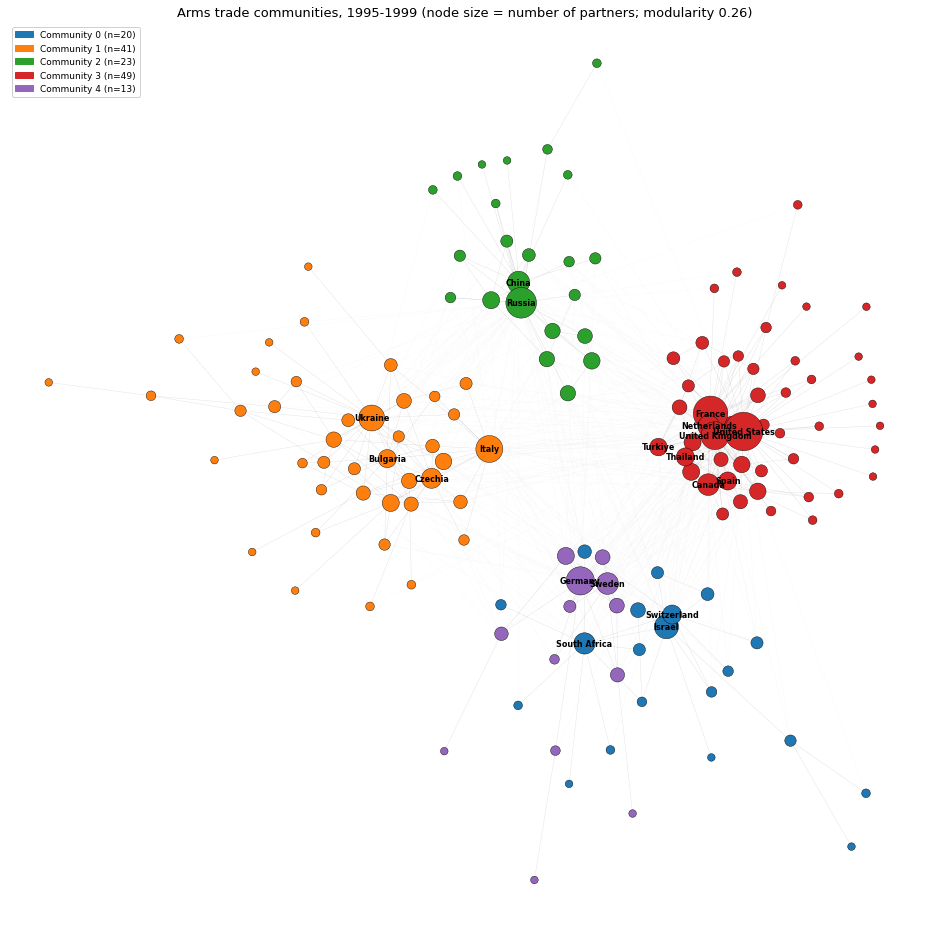

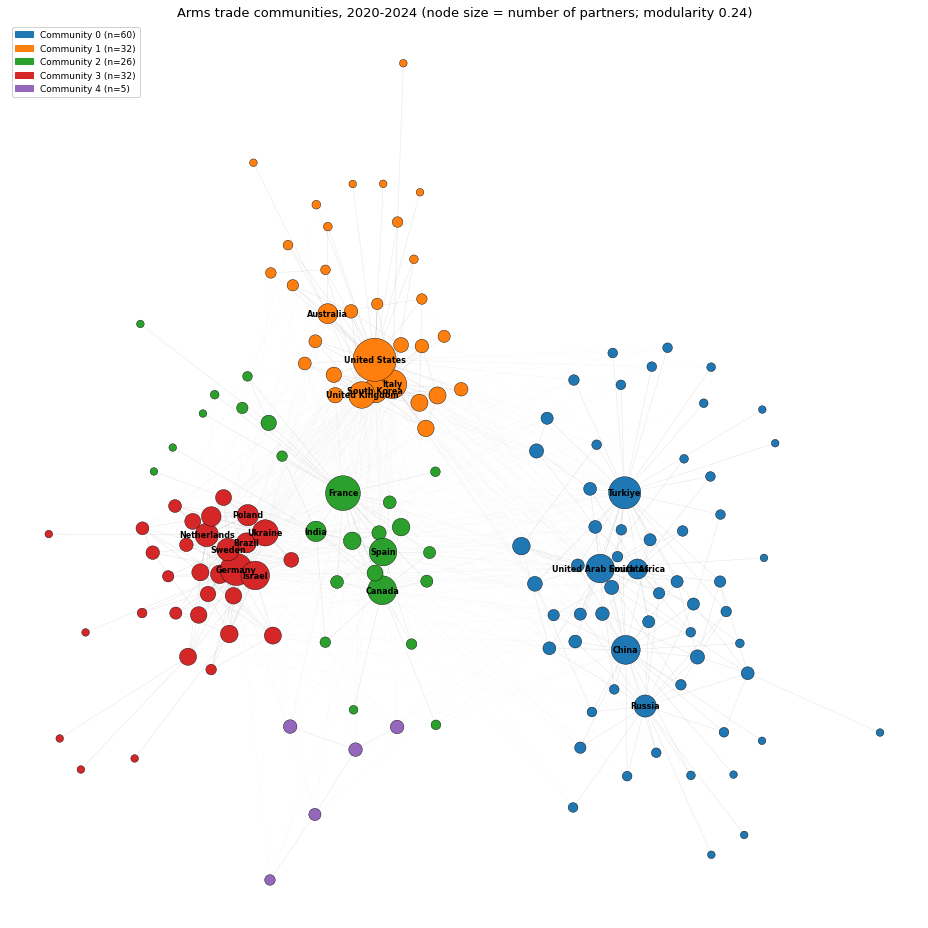

In [32]:
plot_blocks(df, "1960-1964")
plot_blocks(df, "1980-1984")
plot_blocks(df, "1995-1999")
plot_blocks(df, "2020-2024")

## STAGE B: multilayer temporal community detection

In [20]:
def run_multilayer(data, windows, resolution=1.0, interslice=0.5):
    graphs = [build_undirected(data, w) for w in windows]
    membership, improv = la.find_partition_temporal(
        graphs,
        la.RBConfigurationVertexPartition,
        interslice_weight=interslice,     # how "sticky" communities are over time
        resolution_parameter=resolution,  # community granularity
        vertex_id_attr="name",            # match the same country across slices
        n_iterations=2,
    )
    return graphs, membership

In [21]:
graphs, membership = run_multilayer(df, ALL_WINDOWS, resolution=1.0, interslice=0.5)
n_comms = len({c for slice_m in membership for c in slice_m})
print(f"\n=== MULTILAYER: {n_comms} communities across {len(ALL_WINDOWS)} slices ===")
for idx, w in enumerate(ALL_WINDOWS):
    m = membership[idx]
    biggest = Counter(m).most_common(1)[0][1]
    print(f"  {w}: {len(set(m))} comms, largest = {biggest} countries")


=== MULTILAYER: 7 communities across 15 slices ===
  1950-1954: 5 comms, largest = 25 countries
  1955-1959: 5 comms, largest = 26 countries
  1960-1964: 5 comms, largest = 29 countries
  1965-1969: 5 comms, largest = 32 countries
  1970-1974: 5 comms, largest = 37 countries
  1975-1979: 5 comms, largest = 47 countries
  1980-1984: 4 comms, largest = 53 countries
  1985-1989: 4 comms, largest = 47 countries
  1990-1994: 4 comms, largest = 48 countries
  1995-1999: 5 comms, largest = 51 countries
  2000-2004: 5 comms, largest = 40 countries
  2005-2009: 5 comms, largest = 46 countries
  2010-2014: 6 comms, largest = 33 countries
  2015-2019: 6 comms, largest = 54 countries
  2020-2024: 4 comms, largest = 61 countries


In [22]:
idx = ALL_WINDOWS.index("1980-1984")
for cid in set(membership[idx]):
    members = [graphs[idx].vs[v]["name"]
               for v in range(graphs[idx].vcount()) if membership[idx][v] == cid]
    print(cid, members)

0 ['Austria', 'Bahamas', 'Bangladesh', 'Barbados', 'Belize', 'Botswana', 'Cameroon', 'Fiji', 'Gambia', 'Ghana', 'Kenya', 'Liberia', 'Malawi', 'Mauritania', 'Nepal', 'New Zealand', 'Nigeria', 'Pakistan', 'Sierra Leone', 'Switzerland', 'United Kingdom']
1 ['Afghanistan', 'Algeria', 'Angola', 'Bulgaria', 'Burundi', 'Cabo Verde', 'Cambodia', 'Central African Republic', 'China', 'Congo', 'Cuba', 'Czechoslovakia', 'DR Congo', 'East Germany (GDR)', 'Egypt', 'Equatorial Guinea', 'Ethiopia', 'Grenada', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Hungary', 'Iran', 'Iraq', 'Italy', 'Laos', 'Lesotho', 'Libya', 'Madagascar', 'Mali', 'Malta', 'Mongolia', 'Mozambique', 'Nicaragua', 'North Korea', 'North Yemen', 'Poland', 'Romania', 'Saudi Arabia', 'Serbia', 'Seychelles', 'Somalia', 'South Yemen', 'Soviet Union', 'Sudan', 'Syria', 'Tanzania', 'Togo', 'Uganda', 'Viet Nam', 'Western Sahara', 'Zambia', 'Zimbabwe']
2 ['Argentina', 'Australia', 'Belgium', 'Bolivia', 'Brazil', 'Brunei', 'Canada', 'Chad', 'Chile',

### Visualisation

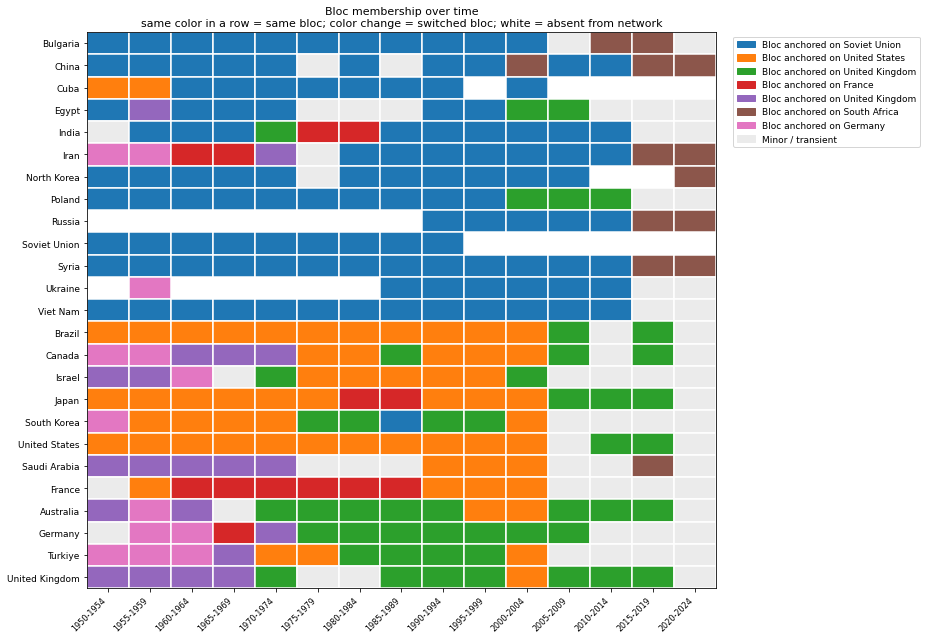

In [36]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import defaultdict, Counter

# run multilayer (seeded for reproducibility)
graphs = [build_undirected(df, w) for w in ALL_WINDOWS]
membership, _ = la.find_partition_temporal(
    graphs, la.RBConfigurationVertexPartition,
    interslice_weight=0.5, resolution_parameter=1.0,
    vertex_id_attr="name", n_iterations=2, seed=42)

# stitch community ids across slices by Jaccard overlap
comms = [defaultdict(set) for _ in ALL_WINDOWS]
for j, g in enumerate(graphs):
    for v in range(g.vcount()):
        comms[j][membership[j][v]].add(g.vs[v]["name"])
jac = lambda a, b: len(a & b) / len(a | b) if a | b else 0
gid, nxt = {}, 0
for c in comms[0]: gid[(0, c)] = nxt; nxt += 1
for j in range(1, len(ALL_WINDOWS)):
    for c, mem in comms[j].items():
        b = max(comms[j-1].items(), key=lambda kv: jac(mem, kv[1]), default=(None, set()))
        gid[(j, c)] = gid[(j-1, b[0])] if b[0] is not None and jac(mem, b[1]) >= 0.3 else nxt
        if gid[(j, c)] == nxt: nxt += 1

# name major lineages by their dominant hub (mechanical) 
lineage = defaultdict(Counter)
slices_of = defaultdict(set)
for j, g in enumerate(graphs):
    deg = dict(zip(g.vs["name"], g.degree()))
    for v in range(g.vcount()):
        gg = gid[(j, membership[j][v])]
        lineage[gg][g.vs[v]["name"]] += deg[g.vs[v]["name"]]
        slices_of[gg].add(j)
major = sorted([g for g in slices_of if len(slices_of[g]) >= 3], key=lambda g: -len(slices_of[g]))
hub = {g: lineage[g].most_common(1)[0][0] for g in major}

# countries to show
track = ["United States","United Kingdom","France","Germany","Canada","Japan",
         "South Korea","Australia","Israel","Brazil","Soviet Union","Russia",
         "China","Ukraine","Poland","Bulgaria","Cuba","North Korea","Viet Nam",
         "India","Egypt","Iran","Syria","Saudi Arabia","Turkiye"]

# matrix + colors
palette = plt.get_cmap("tab10")
color_for = {g: palette(i % 10) for i, g in enumerate(major)}
M = np.full((len(track), len(ALL_WINDOWS)), -1)
for j, g in enumerate(graphs):
    n2c = {g.vs[v]["name"]: membership[j][v] for v in range(g.vcount())}
    for i, c in enumerate(track):
        if c in n2c: M[i, j] = gid[(j, n2c[c])]

# order rows by dominant lineage so similar trajectories sit together
def dom(i):
    vals = [M[i, j] for j in range(len(ALL_WINDOWS)) if M[i, j] != -1]
    return Counter(vals).most_common(1)[0][0] if vals else 999
order = sorted(range(len(track)), key=lambda i: (dom(i), track[i]))
track = [track[i] for i in order]; M = M[order]

# --- plot ---
fig, ax = plt.subplots(figsize=(13, 9))
for i in range(len(track)):
    for j in range(len(ALL_WINDOWS)):
        if M[i, j] == -1: continue
        col = color_for.get(M[i, j], (0.92, 0.92, 0.92, 1))
        ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, facecolor=col,
                                   edgecolor="white", lw=1.5))
ax.set_xlim(-0.5, len(ALL_WINDOWS)-0.5); ax.set_ylim(len(track)-0.5, -0.5)
ax.set_xticks(range(len(ALL_WINDOWS))); ax.set_xticklabels(ALL_WINDOWS, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(track))); ax.set_yticklabels(track, fontsize=9)
ax.set_title("Bloc membership over time\nsame color in a row = same bloc; "
             "color change = switched bloc; white = absent from network", fontsize=11)
handles = [mpatches.Patch(color=color_for[g], label=f"Bloc anchored on {hub[g]}") for g in major]
handles.append(mpatches.Patch(color=(0.92,0.92,0.92,1), label="Minor / transient"))
ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

## Problems

### Degree distribution plot

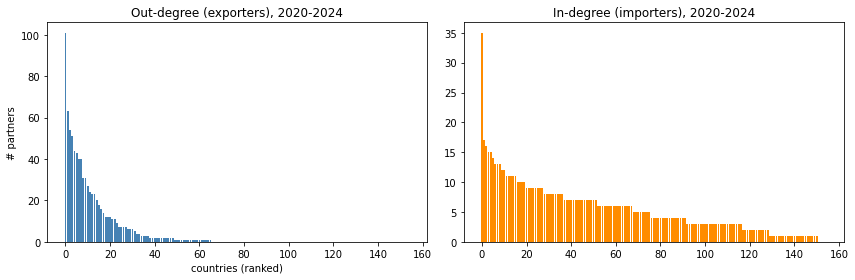

In [25]:
import matplotlib.pyplot as plt

def degree_plot(data, window):
    gd = build_directed(data, window)
    outd = sorted(gd.outdegree(), reverse=True)
    ind  = sorted(gd.indegree(),  reverse=True)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].bar(range(len(outd)), outd, color="steelblue")
    ax[0].set_title(f"Out-degree (exporters), {window}")
    ax[0].set_xlabel("countries (ranked)"); ax[0].set_ylabel("# partners")
    ax[1].bar(range(len(ind)), ind, color="darkorange")
    ax[1].set_title(f"In-degree (importers), {window}")
    plt.tight_layout(); plt.show()

degree_plot(df, "2020-2024")

The degree distribution reveals a star-like (core-periphery) structure: a few hub exporters with very high out-degree and a large number of importers with low in-degree. This is why community detection might yield low modularity.

###  Resolution sweep

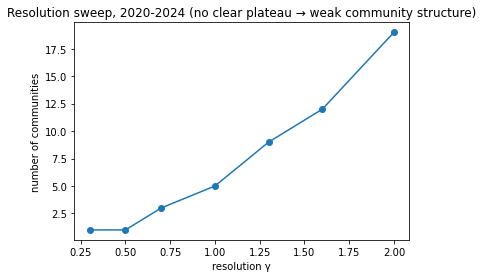

In [28]:
def sweep_plot(data, window, resolutions=[0.3,0.5,0.7,1.0,1.3,1.6,2.0]):
    g = build_undirected(data, window)
    n = [len(g.community_multilevel(resolution=r)) for r in resolutions]
    plt.plot(resolutions, n, "o-")
    plt.xlabel("resolution γ"); plt.ylabel("number of communities")
    plt.title(f"Resolution sweep, {window} (no clear plateau → weak community structure)")
    plt.show()

sweep_plot(df, "2020-2024")

The only stable region is the degenerate split into two giant communities (γ ≈ 0.5–0.75); at any substantive number of communities the count grows monotonically with γ, with no stable plateau. This indicates the absence of well-defined modular structure beyond a coarse two-way division, so we use the default γ = 1.0, which yields an interpretable number of groups.

### + Low modularity